# 04 — Person-Days Analysis

Mirrors `03_threshold_analysis` but expresses heat exposure as **person-days** —
the pixel-wise product of heat-day count and population, summed to neighbourhood level.

Person-days are an extensive quantity: a neighbourhood with 5 000 people experiencing
200 heat days contributes 1 000 000 person-days of exposure.

**Prerequisites:**
- `01_data_acquisition` (temperature + population download)
- `02_compute_baselines` (percentile baselines + population-to-1km resampling)

## Setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils.heat import (
    CITIES,
    load_city,
    load_baseline,
    load_neighbourhood_boundaries,
    compute_absolute_heat_days,
    compute_relative_heat_days,
    compute_person_days_map,
    aggregate_to_neighbourhoods,
    aggregate_person_days_to_neighbourhoods,
    plot_person_days_maps,
    plot_person_days_quadrant,
    plot_population_heat_scatter,
)

In [2]:
# Analysis parameters — edit here, not inside functions
DATA_DIR        = 'data'
YEAR            = 2020          # representative year for spatial maps
PERCENTILE      = 90            # relative-threshold percentile for maps and quadrant
ABS_THRESHOLD   = 30.0          # absolute Tmax threshold in degrees C
CITY_KEYS       = ['salvador', 'teresina', 'caceres']
ALL_YEARS       = list(range(2003, 2021))

# Load all Tmax DataArrays and baselines (fast — local disk only)
cities    = {c: load_city(c, DATA_DIR) for c in CITY_KEYS}
baselines = {c: load_baseline(c, DATA_DIR) for c in CITY_KEYS}

# Load neighbourhood boundaries
gdfs = {c: load_neighbourhood_boundaries(c, DATA_DIR) for c in CITY_KEYS}


def load_pop_grid(city: str, year: int) -> xr.DataArray:
    """Load cached 1km population grid for a city and year."""
    path = f'{DATA_DIR}/{city}_pop_1km_{year}.nc'
    if not os.path.exists(path):
        raise FileNotFoundError(f'{path} not found — run 02_compute_baselines population section first.')
    return xr.open_dataset(path)['population']

salvador: shape {'time': 6497, 'lat': 55, 'lon': 67}  2003-01-01 to 2020-12-30
teresina: shape {'time': 6497, 'lat': 67, 'lon': 78}  2003-01-01 to 2020-12-30
caceres: shape {'time': 6497, 'lat': 89, 'lon': 89}  2003-01-01 to 2020-12-30
salvador baseline: percentiles [50, 75, 90, 95, 99], shape {'percentile': 5, 'lat': 55, 'lon': 67}
teresina baseline: percentiles [50, 75, 90, 95, 99], shape {'percentile': 5, 'lat': 67, 'lon': 78}
caceres baseline: percentiles [50, 75, 90, 95, 99], shape {'percentile': 5, 'lat': 89, 'lon': 89}
Loaded 22 neighbourhoods from cache: data/geobr_salvador_neighbourhoods_2010.gpkg
Loaded 112 neighbourhoods from cache: data/geobr_teresina_neighbourhoods_2010.gpkg
Loaded 43 neighbourhoods from cache: data/geobr_caceres_neighbourhoods_2010.gpkg


## Spatial maps

Side-by-side choropleth maps for each city showing neighbourhood-level **total person-days**
of heat exposure under two threshold framings:

- **Absolute:** days where Tmax >= 30 °C × population per pixel, summed to neighbourhood
- **Relative:** days where Tmax exceeds each pixel's own 90th-percentile baseline × population

Colour is rank-based so within-city variation is always visible.

### Salvador

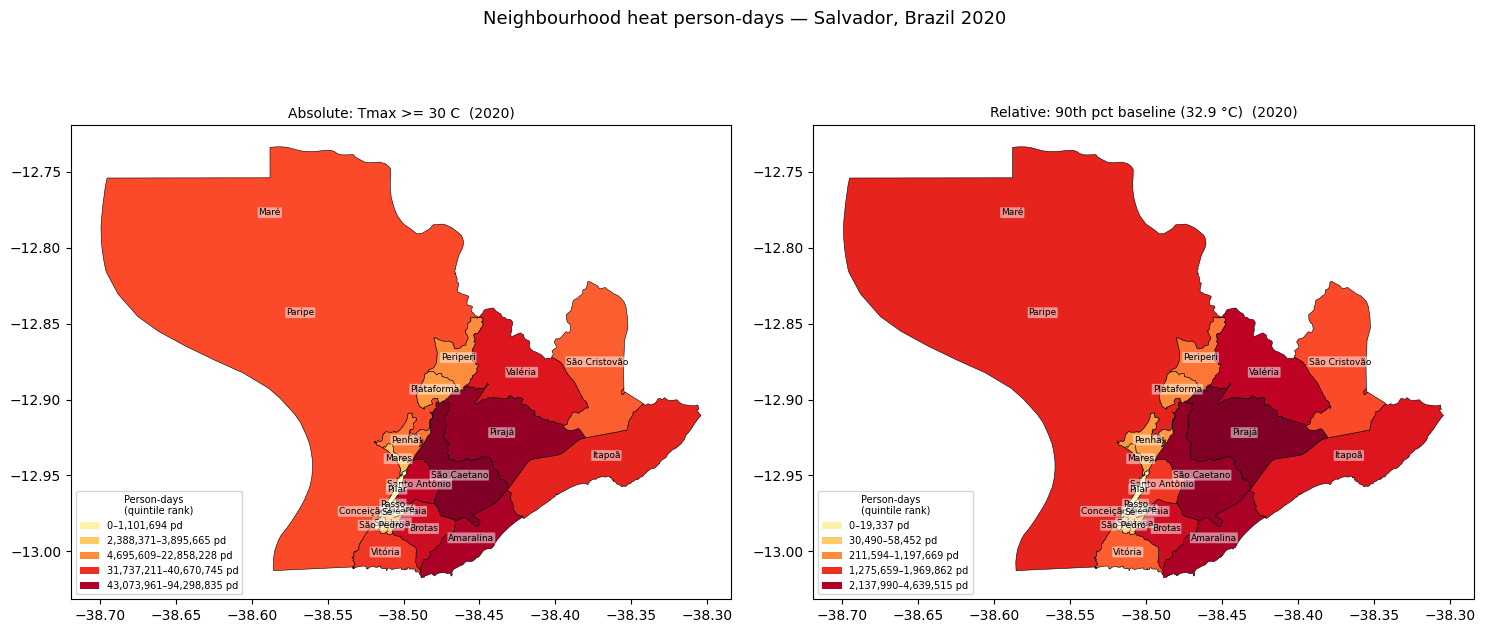

In [3]:
pop_sal = load_pop_grid('salvador', YEAR)
abs_pd_sal, rel_pd_sal = plot_person_days_maps(
    cities['salvador'], gdfs['salvador'], YEAR, PERCENTILE,
    baselines['salvador'], pop_sal, ABS_THRESHOLD, CITIES['salvador']['label'],
)

### Teresina

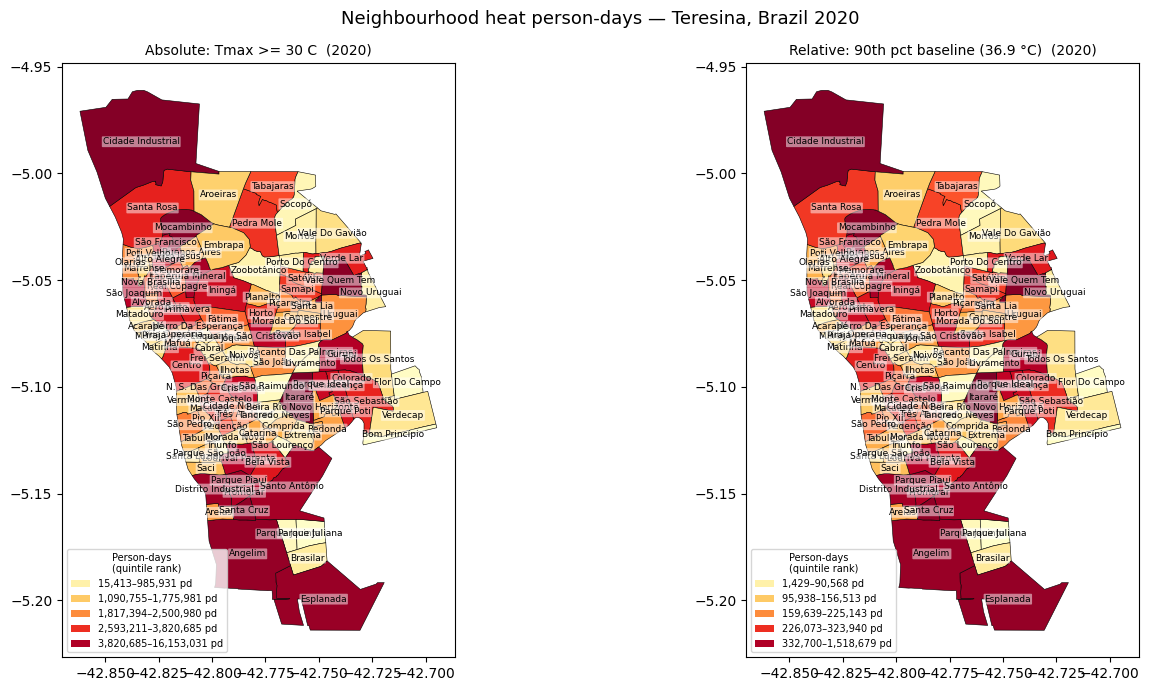

In [4]:
pop_ter = load_pop_grid('teresina', YEAR)
abs_pd_ter, rel_pd_ter = plot_person_days_maps(
    cities['teresina'], gdfs['teresina'], YEAR, PERCENTILE,
    baselines['teresina'], pop_ter, ABS_THRESHOLD, CITIES['teresina']['label'],
)

### Cáceres

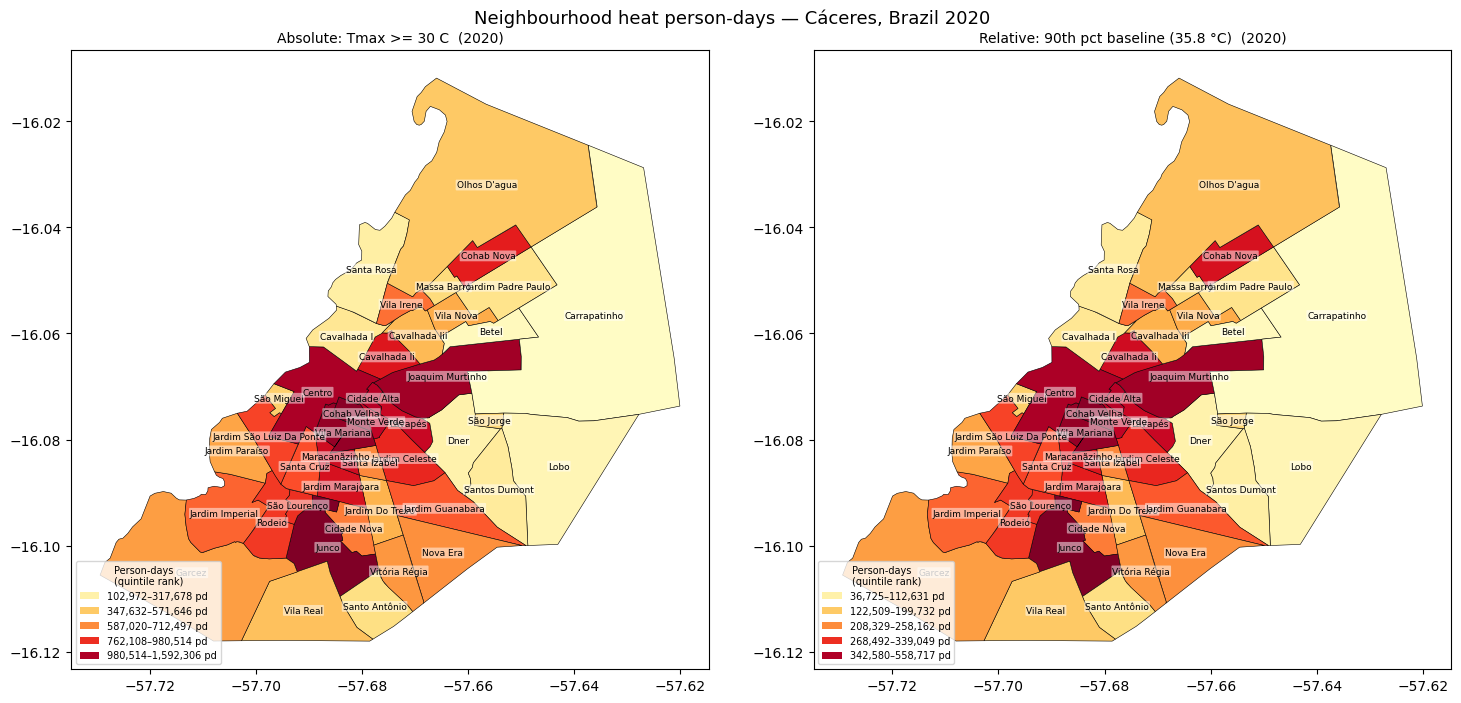

In [5]:
pop_cac = load_pop_grid('caceres', YEAR)
abs_pd_cac, rel_pd_cac = plot_person_days_maps(
    cities['caceres'], gdfs['caceres'], YEAR, PERCENTILE,
    baselines['caceres'], pop_cac, ABS_THRESHOLD, CITIES['caceres']['label'],
)

## Population vs heat exposure

Scatter of neighbourhood population (x) vs mean heat days (y).  Points in the
**top-right quadrant** combine large populations with high heat-day counts — the
priority neighbourhoods regardless of whether person-days are ranked by population
or heat intensity.  The top 5 by combined score are labelled.

### Salvador

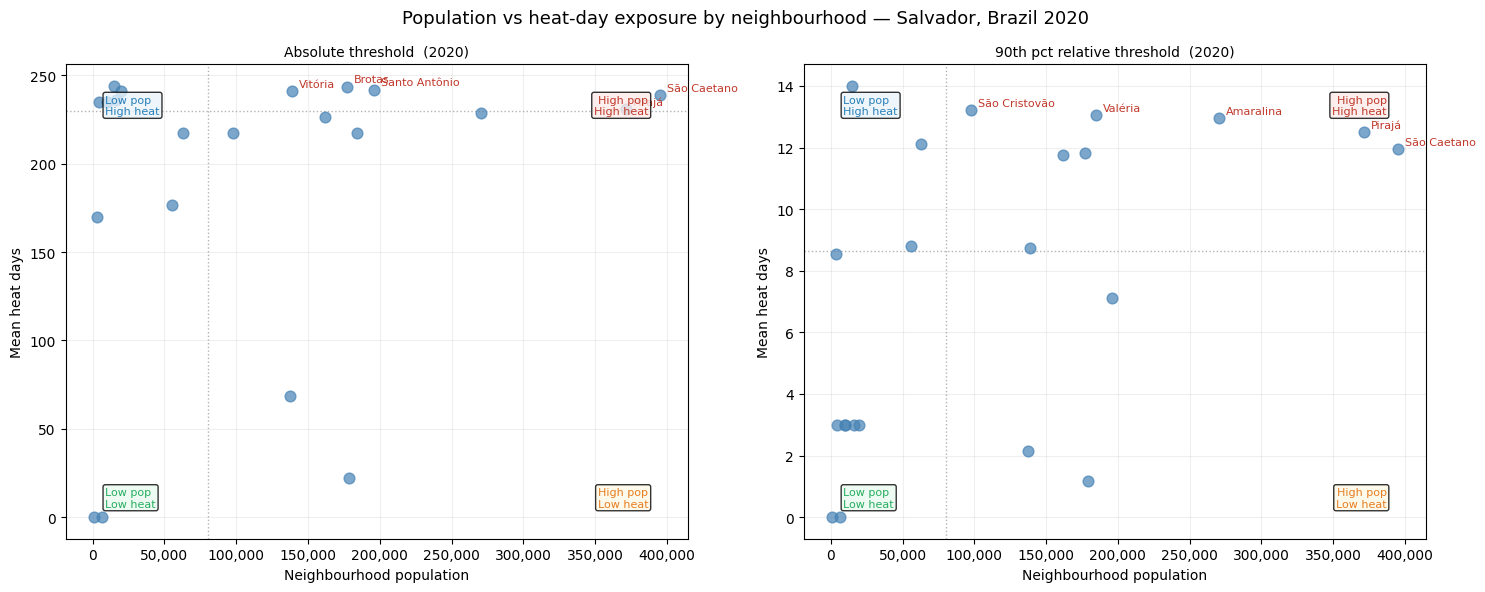

In [6]:
abs_map_sal  = compute_absolute_heat_days(cities['salvador'], YEAR, ABS_THRESHOLD)
rel_map_sal  = compute_relative_heat_days(cities['salvador'], YEAR, baselines['salvador'].sel(percentile=PERCENTILE))
abs_nbhd_sal = aggregate_to_neighbourhoods(abs_map_sal, gdfs['salvador'])
rel_nbhd_sal = aggregate_to_neighbourhoods(rel_map_sal, gdfs['salvador'])
pop_nbhd_sal = aggregate_person_days_to_neighbourhoods(pop_sal, gdfs['salvador'])

plot_population_heat_scatter(abs_nbhd_sal, rel_nbhd_sal, pop_nbhd_sal, YEAR, PERCENTILE, CITIES['salvador']['label'])

### Teresina

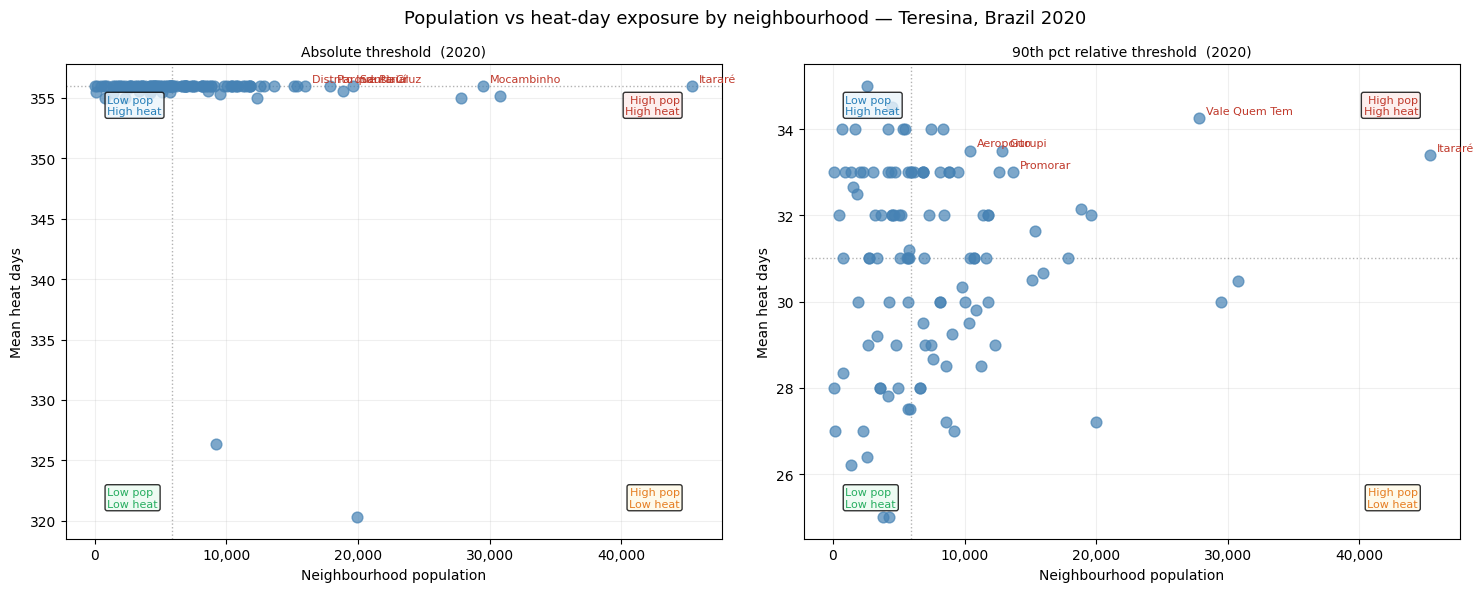

In [7]:
abs_map_ter  = compute_absolute_heat_days(cities['teresina'], YEAR, ABS_THRESHOLD)
rel_map_ter  = compute_relative_heat_days(cities['teresina'], YEAR, baselines['teresina'].sel(percentile=PERCENTILE))
abs_nbhd_ter = aggregate_to_neighbourhoods(abs_map_ter, gdfs['teresina'])
rel_nbhd_ter = aggregate_to_neighbourhoods(rel_map_ter, gdfs['teresina'])
pop_nbhd_ter = aggregate_person_days_to_neighbourhoods(pop_ter, gdfs['teresina'])

plot_population_heat_scatter(abs_nbhd_ter, rel_nbhd_ter, pop_nbhd_ter, YEAR, PERCENTILE, CITIES['teresina']['label'])

### Cáceres

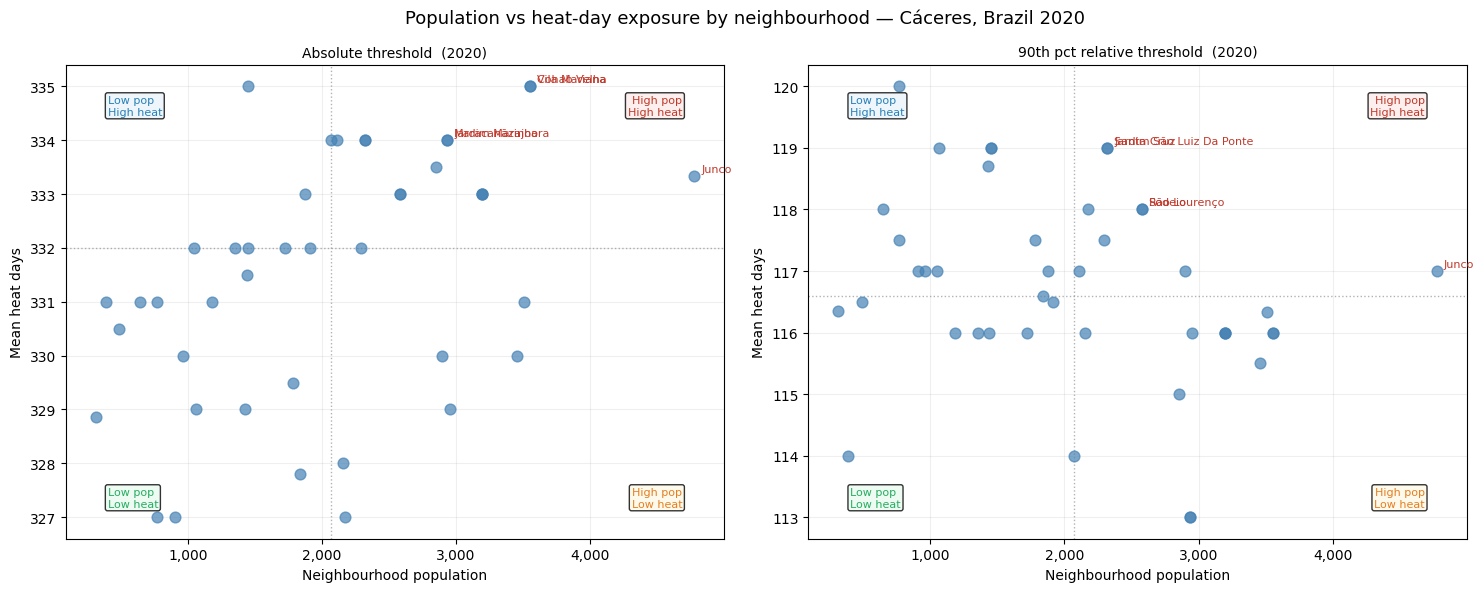

In [8]:
abs_map_cac  = compute_absolute_heat_days(cities['caceres'], YEAR, ABS_THRESHOLD)
rel_map_cac  = compute_relative_heat_days(cities['caceres'], YEAR, baselines['caceres'].sel(percentile=PERCENTILE))
abs_nbhd_cac = aggregate_to_neighbourhoods(abs_map_cac, gdfs['caceres'])
rel_nbhd_cac = aggregate_to_neighbourhoods(rel_map_cac, gdfs['caceres'])
pop_nbhd_cac = aggregate_person_days_to_neighbourhoods(pop_cac, gdfs['caceres'])

plot_population_heat_scatter(abs_nbhd_cac, rel_nbhd_cac, pop_nbhd_cac, YEAR, PERCENTILE, CITIES['caceres']['label'])

## Neighbourhood prioritisation

Rank each neighbourhood simultaneously on absolute and relative person-days.
Neighbourhoods in the top-right quadrant (high rank on both framings) are
robust priorities — large population exposed to many heat days regardless of
which threshold method is applied.

Spearman rho quantifies rank agreement; values near 1 mean framing choice
barely alters the prioritisation.

### Salvador

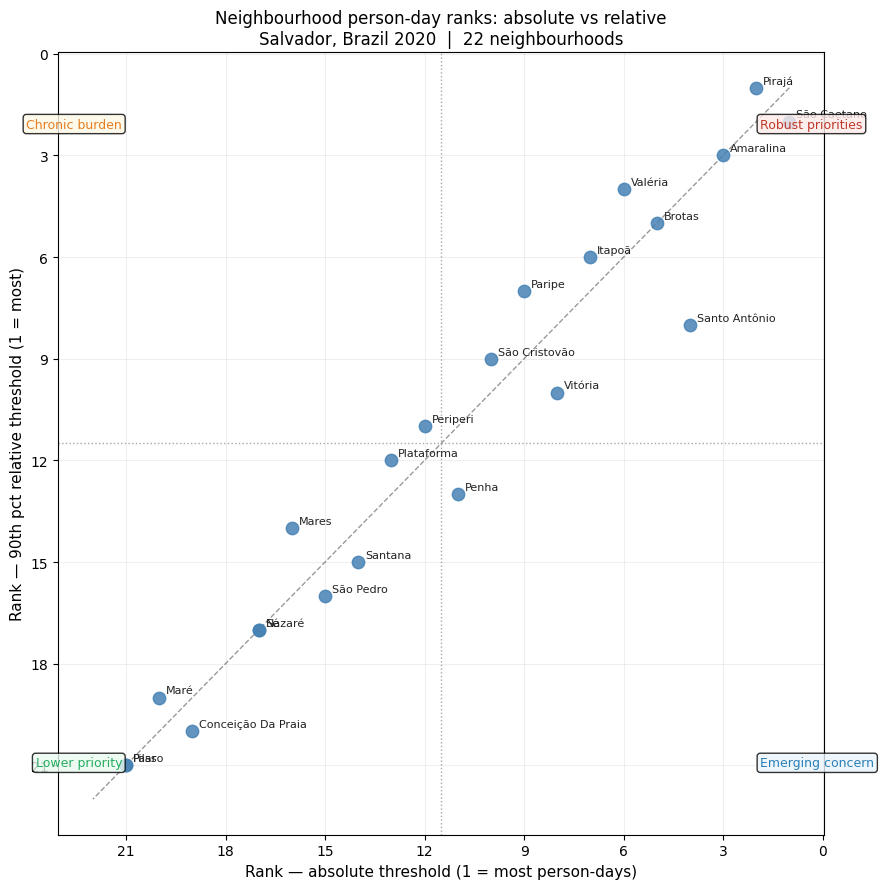

Spearman rho = 0.974  (p = <0.001,  n = 22)


In [9]:
plot_person_days_quadrant(abs_pd_sal, rel_pd_sal, YEAR, PERCENTILE, CITIES['salvador']['label'])

### Teresina

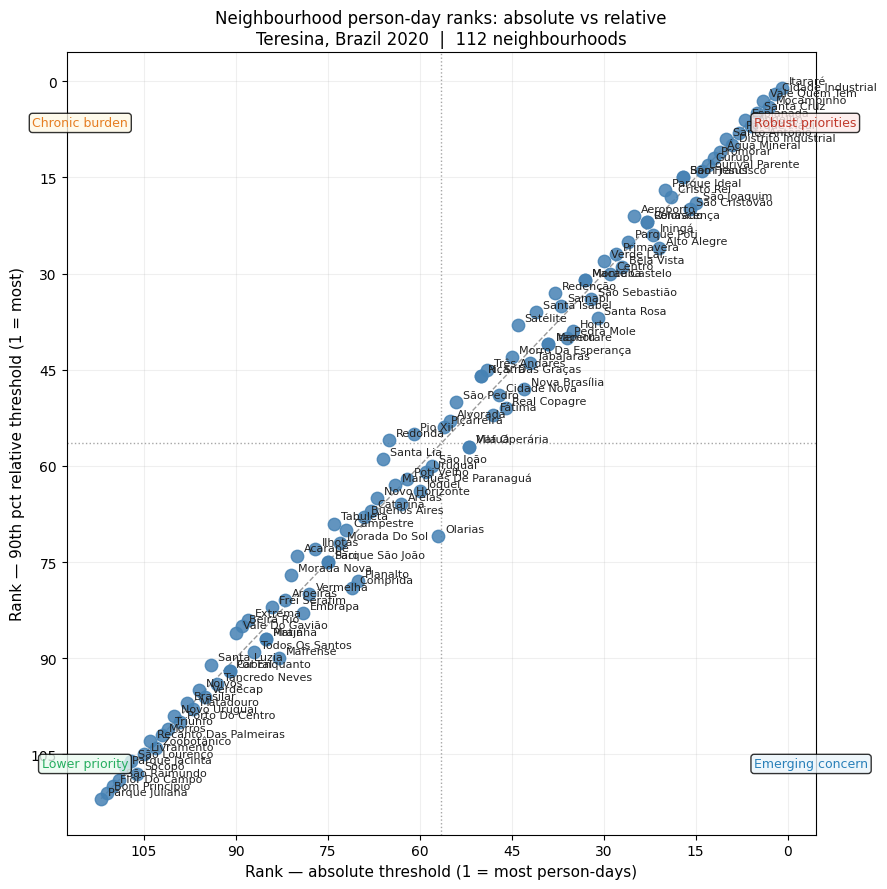

Spearman rho = 0.995  (p = <0.001,  n = 112)


In [10]:
plot_person_days_quadrant(abs_pd_ter, rel_pd_ter, YEAR, PERCENTILE, CITIES['teresina']['label'])

### Cáceres

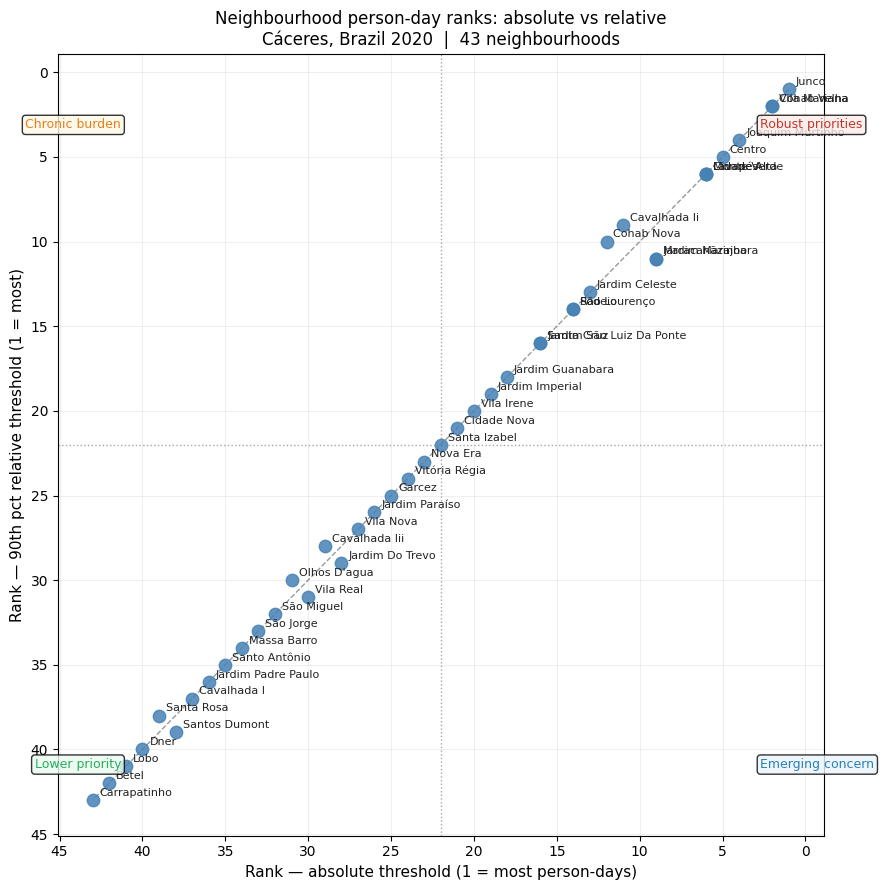

Spearman rho = 0.998  (p = <0.001,  n = 43)


In [11]:
plot_person_days_quadrant(abs_pd_cac, rel_pd_cac, YEAR, PERCENTILE, CITIES['caceres']['label'])

## Annual person-days time series — 2003–2020

City-wide total person-days per year (sum across all pixels) for each threshold.
Trends capture both changing heat-day frequency *and* population growth.

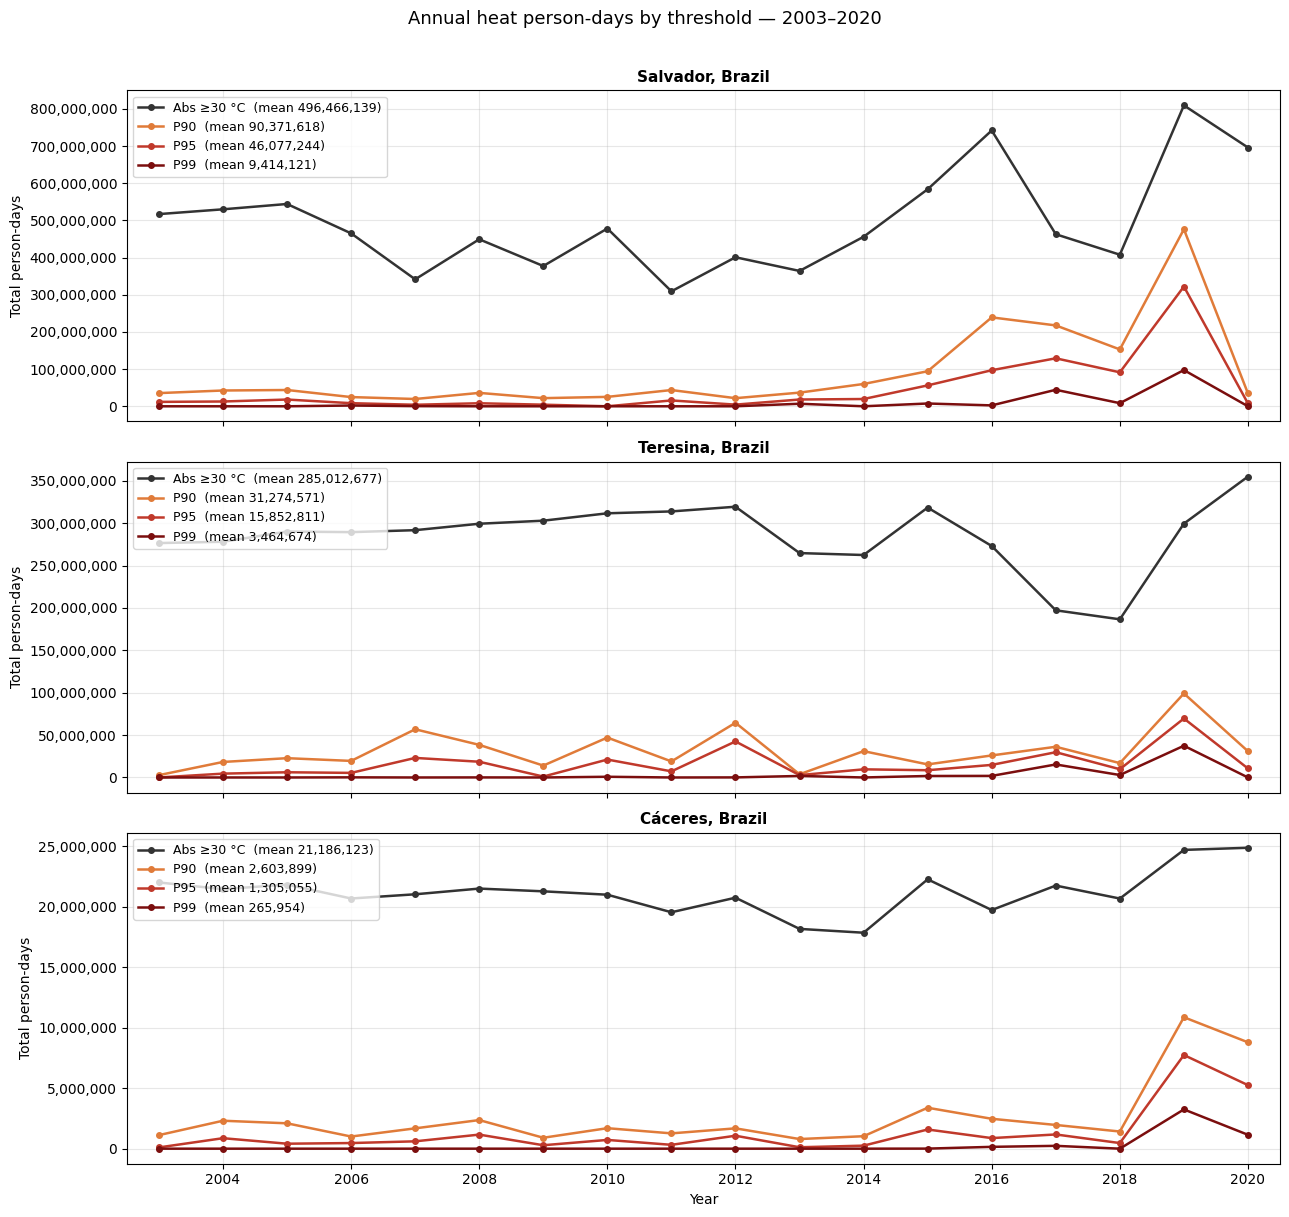

,Abs ≥30 °C,P90,P95,P99
City,,,,
"Salvador, Brazil","496,466,139","90,371,618","46,077,244","9,414,121"
"Teresina, Brazil","285,012,677","31,274,571","15,852,811","3,464,674"
"Cáceres, Brazil","21,186,123","2,603,899","1,305,055","265,954"


In [12]:
THRESHOLDS = {
    f'Abs \u2265{ABS_THRESHOLD:.0f} \u00b0C': None,
    'P90': 90,
    'P95': 95,
    'P99': 99,
}
COLOURS = {
    f'Abs \u2265{ABS_THRESHOLD:.0f} \u00b0C': '#333333',
    'P90': '#e07b39',
    'P95': '#c0392b',
    'P99': '#7b0e0e',
}

fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True, sharey=False)

period_rows = []

for ax, c in zip(axes, CITY_KEYS):
    label    = CITIES[c]['label']
    da       = cities[c]
    baseline = baselines[c]
    period_row = {'City': label}

    for thr_label, pct in THRESHOLDS.items():
        annual_pd = []
        for yr in ALL_YEARS:
            pop_grid = load_pop_grid(c, yr)
            if pct is None:
                heat_map = compute_absolute_heat_days(da, yr, ABS_THRESHOLD)
            else:
                heat_map = compute_relative_heat_days(da, yr, baseline.sel(percentile=pct))
            pd_map = compute_person_days_map(heat_map, pop_grid)
            annual_pd.append(float(pd_map.sum()))

        period_mean = float(np.mean(annual_pd))
        period_row[thr_label] = period_mean

        ax.plot(ALL_YEARS, annual_pd, marker='o', markersize=4, linewidth=1.8,
                color=COLOURS[thr_label], label=f'{thr_label}  (mean {period_mean:,.0f})')

    period_rows.append(period_row)

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Total person-days')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(ALL_YEARS[0] - 0.5, ALL_YEARS[-1] + 0.5)
    ax.xaxis.set_major_locator(plt.MultipleLocator(2))

axes[-1].set_xlabel('Year')
fig.suptitle('Annual heat person-days by threshold \u2014 2003\u20132020', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Period-average summary table
period_df = pd.DataFrame(period_rows).set_index('City')
table_styles = [
    {'selector': 'caption', 'props': 'font-size:1em; font-weight:bold; padding-bottom:8px;'},
    {'selector': 'th', 'props': 'text-align:center; white-space:nowrap;'},
    {'selector': 'td', 'props': 'text-align:center;'},
]
display(
    period_df.style
    .format('{:,.0f}')
    .background_gradient(cmap='YlOrRd', axis=None, vmin=0)
    .set_caption('2003\u20132020 period averages \u2014 mean annual city-wide person-days')
    .set_table_styles(table_styles)
)

## Threshold comparison summary

Average annual person-days per city (2003–2020) under one absolute threshold
and three relative thresholds. Person-days combine heat frequency with population
size, so cities with similar heat-day counts can differ substantially here.

In [13]:
REL_PERCENTILES = [90, 95, 99]

count_rows = []
temp_rows  = []

for c in CITY_KEYS:
    da       = cities[c]
    baseline = baselines[c]
    label    = CITIES[c]['label']

    count_row = {'City': label}
    temp_row  = {'City': label}

    abs_annual = []
    for yr in ALL_YEARS:
        pop_grid = load_pop_grid(c, yr)
        heat_map = compute_absolute_heat_days(da, yr, ABS_THRESHOLD)
        abs_annual.append(float(compute_person_days_map(heat_map, pop_grid).sum()))
    count_row[f'Abs \u2265{ABS_THRESHOLD:.0f} \u00b0C'] = float(np.mean(abs_annual))

    for p in REL_PERCENTILES:
        pct_map = baseline.sel(percentile=p)
        rel_annual = []
        for yr in ALL_YEARS:
            pop_grid = load_pop_grid(c, yr)
            heat_map = compute_relative_heat_days(da, yr, pct_map)
            rel_annual.append(float(compute_person_days_map(heat_map, pop_grid).sum()))
        count_row[f'P{p}'] = float(np.mean(rel_annual))
        temp_row[f'P{p} (\u00b0C)'] = float(pct_map.mean())

    count_rows.append(count_row)
    temp_rows.append(temp_row)

counts = pd.DataFrame(count_rows).set_index('City')
temps  = pd.DataFrame(temp_rows).set_index('City')

table_styles = [
    {'selector': 'caption', 'props': 'font-size:1em; font-weight:bold; padding-bottom:8px;'},
    {'selector': 'th', 'props': 'text-align:center; white-space:nowrap;'},
    {'selector': 'td', 'props': 'text-align:center;'},
]

display(
    counts.style
    .format('{:,.0f}')
    .background_gradient(cmap='YlOrRd', axis=None, vmin=0)
    .set_caption('Average annual person-days per city \u2014 2003\u20132020  (city-wide total)')
    .set_table_styles(table_styles)
)

print()

display(
    temps.style
    .format('{:.1f}')
    .set_caption('Percentile baseline temperatures by city  (spatial mean \u00b0C)')
    .set_table_styles(table_styles)
)

# --- Coefficient of variation diagnostic ---
# Compares spread of person-days vs spread of raw population across neighbourhoods.
# If population CV >> person-days CV, population is dominating the ranking signal.
print('\n--- CV diagnostic: does population dominate person-days ranking? ---')
for c, abs_gdf, rel_gdf in zip(
    CITY_KEYS,
    [abs_pd_sal, abs_pd_ter, abs_pd_cac],
    [rel_pd_sal, rel_pd_ter, rel_pd_cac],
):
    label = CITIES[c]['label']
    abs_cv = abs_gdf['total_person_days'].std() / abs_gdf['total_person_days'].mean()
    rel_cv = rel_gdf['total_person_days'].std() / rel_gdf['total_person_days'].mean()
    pop_g    = load_pop_grid(c, YEAR)
    pop_nbhd = aggregate_person_days_to_neighbourhoods(pop_g, gdfs[c], col='total_person_days')
    pop_cv   = pop_nbhd['total_person_days'].std() / pop_nbhd['total_person_days'].mean()
    print(f'\n{label}')
    print(f'  person-days CV:  abs={abs_cv:.3f}  rel={rel_cv:.3f}')
    print(f'  population CV:   {pop_cv:.3f}')

,Abs ≥30 °C,P90,P95,P99
City,,,,
"Salvador, Brazil","496,466,139","90,371,618","46,077,244","9,414,121"
"Teresina, Brazil","285,012,677","31,274,571","15,852,811","3,464,674"
"Cáceres, Brazil","21,186,123","2,603,899","1,305,055","265,954"


,P90 (°C),P95 (°C),P99 (°C)
City,,,
"Salvador, Brazil",32.9,33.6,36.1
"Teresina, Brazil",36.9,37.8,40.9
"Cáceres, Brazil",35.8,37.0,40.2



--- CV diagnostic: does population dominate person-days ranking? ---

Salvador, Brazil
  person-days CV:  abs=1.099  rel=1.195
  population CV:   1.041

Teresina, Brazil
  person-days CV:  abs=0.877  rel=0.909
  population CV:   0.878

Cáceres, Brazil
  person-days CV:  abs=0.508  rel=0.502
  population CV:   0.506


## Summary

Key outputs from this notebook:

1. **Spatial maps** — person-days exposure at neighbourhood level reveals how population
   distribution amplifies or dampens the raw heat-day signal.

2. **Quadrant plots** — identify neighbourhoods that are robustly high-burden on *both*
   absolute and relative framings, accounting for population size.

3. **Time series** — city-wide annual totals from 2003–2020 combine heat-day trends
   with population growth; divergence between thresholds highlights locally-calibrated
   vs cross-city framing.

4. **Summary table** — average annual person-days per city/threshold for cross-city comparison.

To change the analysis year or threshold, edit the parameters in the Setup cell and re-run.